# 04 — Logistic Regression Baseline

**Project:** Financial Fraud Detection System  
**Step:** 7.2 — Logistic Regression Baseline  
**Dataset:** `data/raw/synthetic_fraud_dataset1 (1).csv`

---

## Objective

This notebook establishes a **Logistic Regression baseline** for the Financial Fraud Detection project.  
The baseline provides a reference point against which future models can be compared.

**Scope of this notebook:**
- Load and prepare the dataset (reproduce cleaning from Step 6 / Step 7.1)
- Create a stratified 80/20 train/test split (same as Step 7.1)
- Build and fit the preprocessing pipeline (only on training data)
- Train ONE Logistic Regression model
- Generate predictions and probabilities
- Evaluate baseline performance (Accuracy, Precision, Recall, F1, ROC-AUC)
- Confusion Matrix and ROC Curve
- Coefficient interpretation
- Validation checks

**Not in scope:** Random Forest, XGBoost, SMOTE, hyperparameter tuning, cross-validation, model serialization, dashboard.

---
## 1. Import Libraries

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

import sklearn
import sys
print(f"Python version:        {sys.version}")
print(f"scikit-learn version:  {sklearn.__version__}")
print(f"pandas version:        {pd.__version__}")
print(f"numpy version:         {np.__version__}")
print("\nAll libraries imported successfully.")

Python version:        3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
scikit-learn version:  1.7.2
pandas version:        2.3.3
numpy version:         2.2.6

All libraries imported successfully.


---
## 2. Load Dataset

In [2]:
# Robust relative path from notebooks/ to the raw data file
DATA_PATH = os.path.join("..", "data", "raw", "synthetic_fraud_dataset1 (1).csv")

raw_df = pd.read_csv(DATA_PATH)
print(f"Raw dataset loaded from: {DATA_PATH}")
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")

# Verify expected dataset dimensions
assert raw_df.shape[0] == 50_000, f"Expected 50,000 rows, got {raw_df.shape[0]:,}"
assert raw_df.shape[1] == 14, f"Expected 14 columns, got {raw_df.shape[1]}"
print("Dataset dimensions verified.")

# Create a working copy (raw CSV is never modified)
df = raw_df.copy()

# --- Reproduce Step 6 cleaning ---

# 1. Convert Date column from string to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d %B %Y", errors="coerce")
nat_count = df["Date"].isna().sum()
print(f"\nDate conversion: {nat_count} unparseable dates (NaT)")

# 2. Extract date-based features (consistent with Step 6)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek  # Monday=0, Sunday=6

print("Date features created: Year, Month, Day, Day_of_Week")
print(f"Working DataFrame shape: {df.shape}")

Raw dataset loaded from: ..\data\raw\synthetic_fraud_dataset1 (1).csv
Shape: 50,000 rows x 14 columns
Dataset dimensions verified.

Date conversion: 0 unparseable dates (NaT)
Date features created: Year, Month, Day, Day_of_Week
Working DataFrame shape: (50000, 18)


---
## 3. Prepare Features and Target

- **Target (`y`):** `Fraud_Label`
- **Features (`X`):** All model input features, excluding identifiers (`Transaction_ID`, `User_ID`), the raw `Date` column, and the target.
- Date-derived features (`Year`, `Month`, `Day`, `Day_of_Week`) are included as numerical features.

In [3]:
# Columns to exclude from model features
exclude_from_X = ["Transaction_ID", "User_ID", "Date", "Fraud_Label"]

# Target
y = df["Fraud_Label"].copy()

# Features (everything except identifiers, raw Date, and target)
X = df.drop(columns=exclude_from_X).copy()

print(f"Target (y): shape = {y.shape}, dtype = {y.dtype}")
print(f"Features (X): shape = {X.shape}")
print(f"\nFeature columns ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col:35s} ({X[col].dtype})")

# Verify target distribution
target_counts = y.value_counts().sort_index()
print(f"\nTarget distribution:")
print(f"  0 (Non-Fraud): {target_counts[0]:,}")
print(f"  1 (Fraud):     {target_counts[1]:,}")
print(f"  Fraud rate:    {target_counts[1] / len(y) * 100:.2f}%")

# --- Data leakage assertions ---
assert "Fraud_Label" not in X.columns, "ERROR: Fraud_Label found in X -- target leakage!"
assert "Transaction_ID" not in X.columns, "ERROR: Transaction_ID found in X!"
assert "User_ID" not in X.columns, "ERROR: User_ID found in X!"
assert len(X) == len(y), "ERROR: X and y have mismatched row counts!"
assert y.isna().sum() == 0, "ERROR: Missing values in target!"
assert set(y.unique()).issubset({0, 1}), "ERROR: Target contains unexpected values!"
print("\nAll feature/target separation validations passed.")

Target (y): shape = (50000,), dtype = int64
Features (X): shape = (50000, 14)

Feature columns (14):
   1. Transaction_Amount                  (float64)
   2. Transaction_Type                    (object)
   3. Account_Balance                     (float64)
   4. Device_Type                         (object)
   5. Location                            (object)
   6. Merchant_Category                   (object)
   7. Previous_Fraudulent_Activity        (int64)
   8. Daily_Transaction_Count             (int64)
   9. Card_Type                           (object)
  10. Card_Age                            (int64)
  11. Year                                (int32)
  12. Month                               (int32)
  13. Day                                 (int32)
  14. Day_of_Week                         (int32)

Target distribution:
  0 (Non-Fraud): 33,933
  1 (Fraud):     16,067
  Fraud rate:    32.13%

All feature/target separation validations passed.


---
## 4. Train/Test Split

Create a stratified 80/20 train/test split to preserve class distribution.  
Using `random_state=42` for reproducibility — same parameters as Step 7.1.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split Complete")
print("=" * 50)
print(f"  Training set:  X_train {X_train.shape}  |  y_train {y_train.shape}")
print(f"  Testing set:   X_test  {X_test.shape}  |  y_test  {y_test.shape}")
print(f"\n  Total rows:    {len(X_train) + len(X_test):,}")
print(f"  Train rows:    {len(X_train):,}  ({len(X_train) / len(X) * 100:.1f}%)")
print(f"  Test rows:     {len(X_test):,}  ({len(X_test) / len(X) * 100:.1f}%)")
print(f"  random_state:  42")
print(f"  stratify:      y")

# Verify sizes
assert len(X_train) == len(y_train), "X_train and y_train row count mismatch!"
assert len(X_test) == len(y_test), "X_test and y_test row count mismatch!"
print("\nSplit sizes verified.")

Train/Test Split Complete
  Training set:  X_train (40000, 14)  |  y_train (40000,)
  Testing set:   X_test  (10000, 14)  |  y_test  (10000,)

  Total rows:    50,000
  Train rows:    40,000  (80.0%)
  Test rows:     10,000  (20.0%)
  random_state:  42
  stratify:      y

Split sizes verified.


---
## 5. Build Preprocessing Pipeline

Recreate the preprocessing design from Step 7.1 using `ColumnTransformer`.  

**Categorical features** -> `OneHotEncoder(drop="first", handle_unknown="ignore")`  
**Numerical features** -> `StandardScaler()`

The numerical features include the 4 date-derived components (`Year`, `Month`, `Day`, `Day_of_Week`)  
in addition to the 5 original numerical columns, for a total of 9 numerical features.

In [5]:
# Define feature groups explicitly
categorical_features = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
]

numerical_features = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
]

# Verify all specified columns exist in the DataFrame
for col in categorical_features + numerical_features:
    assert col in X_train.columns, f"ERROR: Column '{col}' not found in X_train!"

# Build ColumnTransformer (consistent with Step 7.1 design)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            StandardScaler(),
            numerical_features,
        ),
    ],
    remainder="drop",
)

print("Preprocessing ColumnTransformer defined:")
print(f"  Categorical -> OneHotEncoder (drop='first', handle_unknown='ignore')")
print(f"    Columns ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical  -> StandardScaler")
print(f"    Columns ({len(numerical_features)}):  {numerical_features}")
print(f"\n  Total input features: {len(categorical_features) + len(numerical_features)}")

Preprocessing ColumnTransformer defined:
  Categorical -> OneHotEncoder (drop='first', handle_unknown='ignore')
    Columns (5): ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']
  Numerical  -> StandardScaler
    Columns (9):  ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Year', 'Month', 'Day', 'Day_of_Week']

  Total input features: 14


---
## 6. Fit Preprocessing on Training Data Only

**Critical for preventing data leakage.**

The preprocessor is fitted **exclusively** on `X_train`.  
The test set (`X_test`) remains completely unseen during the fitting process.

In [6]:
# Fit the preprocessor ONLY on training data
preprocessor.fit(X_train)

# Transform both sets using the preprocessor fitted on X_train
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names from the fitted preprocessor
transformed_feature_names = preprocessor.get_feature_names_out()

print("Preprocessor fitted on X_train ONLY.")
print(f"  Training samples used for fitting: {len(X_train):,}")
print(f"  Test samples kept unseen: {len(X_test):,}")
print(f"\nTransformation Complete")
print("=" * 50)
print(f"  X_train_processed shape: {X_train_processed.shape}")
print(f"  X_test_processed shape:  {X_test_processed.shape}")
print(f"  Number of transformed features: {len(transformed_feature_names)}")

# Validate processed shapes
assert X_train_processed.shape[0] == X_train.shape[0], "Train row count mismatch after transform!"
assert X_test_processed.shape[0] == X_test.shape[0], "Test row count mismatch after transform!"
assert X_train_processed.shape[1] == X_test_processed.shape[1], "Train/test column count mismatch!"

# Verify preprocessor was fitted on training data only
num_transformer = preprocessor.named_transformers_["num"]
assert num_transformer.n_samples_seen_ == len(X_train), \
    f"Preprocessor fitted on {num_transformer.n_samples_seen_} samples, expected {len(X_train)}!"
print(f"\nConfirmed: preprocessor fitted on {num_transformer.n_samples_seen_:,} training samples only.")

Preprocessor fitted on X_train ONLY.
  Training samples used for fitting: 40,000
  Test samples kept unseen: 10,000

Transformation Complete
  X_train_processed shape: (40000, 25)
  X_test_processed shape:  (10000, 25)
  Number of transformed features: 25

Confirmed: preprocessor fitted on 40,000 training samples only.


---
## 7. Train Logistic Regression Baseline

Train a single Logistic Regression model as the **baseline**.  
No hyperparameter tuning, no cross-validation — just a simple, reproducible baseline.

In [7]:
# Train ONE Logistic Regression baseline model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression Baseline -- Training Complete")
print("=" * 50)
print(f"  Model: {logistic_model.__class__.__name__}")
print(f"  Solver: {logistic_model.solver}")
print(f"  max_iter: {logistic_model.max_iter}")
print(f"  random_state: {logistic_model.random_state}")
print(f"  C (regularization): {logistic_model.C}")
print(f"  Penalty: {logistic_model.penalty}")
print(f"  Convergence iterations: {logistic_model.n_iter_[0]}")
print(f"  Number of features seen: {logistic_model.n_features_in_}")
print(f"  Number of training samples: {X_train_processed.shape[0]:,}")
print(f"  Classes: {logistic_model.classes_}")

# Verify model is fitted
assert hasattr(logistic_model, 'coef_'), "ERROR: Model was not fitted!"
assert hasattr(logistic_model, 'intercept_'), "ERROR: Model has no intercept!"
assert logistic_model.n_features_in_ == X_train_processed.shape[1], \
    "ERROR: Model feature count does not match processed data!"
print("\nLogistic Regression model trained and verified.")

Logistic Regression Baseline -- Training Complete
  Model: LogisticRegression
  Solver: lbfgs
  max_iter: 1000
  random_state: 42
  C (regularization): 1.0
  Penalty: l2
  Convergence iterations: 15
  Number of features seen: 25
  Number of training samples: 40,000
  Classes: [0 1]

Logistic Regression model trained and verified.


---
## 8. Generate Predictions and Probabilities

In [8]:
# Generate predictions (hard labels)
y_train_pred = logistic_model.predict(X_train_processed)
y_test_pred = logistic_model.predict(X_test_processed)

# Generate probabilities (for ROC-AUC)
y_train_proba = logistic_model.predict_proba(X_train_processed)[:, 1]  # P(Fraud=1)
y_test_proba = logistic_model.predict_proba(X_test_processed)[:, 1]    # P(Fraud=1)

print("Predictions and Probabilities Generated")
print("=" * 50)
print(f"  y_train_pred shape:  {y_train_pred.shape}")
print(f"  y_test_pred shape:   {y_test_pred.shape}")
print(f"  y_train_proba shape: {y_train_proba.shape}")
print(f"  y_test_proba shape:  {y_test_proba.shape}")

# Validate predictions
assert len(y_train_pred) == len(y_train), "Train prediction length mismatch!"
assert len(y_test_pred) == len(y_test), "Test prediction length mismatch!"
assert len(y_train_proba) == len(y_train), "Train probability length mismatch!"
assert len(y_test_proba) == len(y_test), "Test probability length mismatch!"
assert set(np.unique(y_train_pred)).issubset({0, 1}), "Train predictions contain invalid values!"
assert set(np.unique(y_test_pred)).issubset({0, 1}), "Test predictions contain invalid values!"
assert y_train_proba.min() >= 0 and y_train_proba.max() <= 1, "Train probabilities out of [0,1]!"
assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1, "Test probabilities out of [0,1]!"

print(f"\n  Train prediction unique values: {np.unique(y_train_pred)}")
print(f"  Test prediction unique values:  {np.unique(y_test_pred)}")
print(f"  Train probability range:  [{y_train_proba.min():.4f}, {y_train_proba.max():.4f}]")
print(f"  Test probability range:   [{y_test_proba.min():.4f}, {y_test_proba.max():.4f}]")
print("\nAll prediction validations passed.")

Predictions and Probabilities Generated
  y_train_pred shape:  (40000,)
  y_test_pred shape:   (10000,)
  y_train_proba shape: (40000,)
  y_test_proba shape:  (10000,)

  Train prediction unique values: [0]
  Test prediction unique values:  [0]
  Train probability range:  [0.2844, 0.3637]
  Test probability range:   [0.2863, 0.3611]

All prediction validations passed.


---
## 9. Evaluate Baseline

Calculate baseline metrics for both training and test sets.  
The **test set** metrics are the primary baseline results.

In [9]:
# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, y_train_proba)

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Logistic Regression Baseline -- Evaluation")
print("=" * 50)
print(f"\n  {'Metric':<15s} {'Train':>10s} {'Test':>10s}")
print(f"  {'-'*15} {'-'*10} {'-'*10}")
print(f"  {'Accuracy':<15s} {train_accuracy:>10.4f} {test_accuracy:>10.4f}")
print(f"  {'Precision':<15s} {train_precision:>10.4f} {test_precision:>10.4f}")
print(f"  {'Recall':<15s} {train_recall:>10.4f} {test_recall:>10.4f}")
print(f"  {'F1-Score':<15s} {train_f1:>10.4f} {test_f1:>10.4f}")
print(f"  {'ROC-AUC':<15s} {train_roc_auc:>10.4f} {test_roc_auc:>10.4f}")

print(f"\n--- Test Set Classification Report ---\n")
print(classification_report(
    y_test, y_test_pred,
    target_names=["Non-Fraud (0)", "Fraud (1)"],
    zero_division=0
))

Logistic Regression Baseline -- Evaluation

  Metric               Train       Test
  --------------- ---------- ----------
  Accuracy            0.6786     0.6787
  Precision           0.0000     0.0000
  Recall              0.0000     0.0000
  F1-Score            0.0000     0.0000
  ROC-AUC             0.5138     0.4903

--- Test Set Classification Report ---

               precision    recall  f1-score   support

Non-Fraud (0)       0.68      1.00      0.81      6787
    Fraud (1)       0.00      0.00      0.00      3213

     accuracy                           0.68     10000
    macro avg       0.34      0.50      0.40     10000
 weighted avg       0.46      0.68      0.55     10000



---
## 10. Confusion Matrix

Visualize the test-set confusion matrix for the Logistic Regression baseline.

Test Set Confusion Matrix
  True Negative  (TN): 6,787
  False Positive (FP): 0
  False Negative (FN): 3,213
  True Positive  (TP): 0


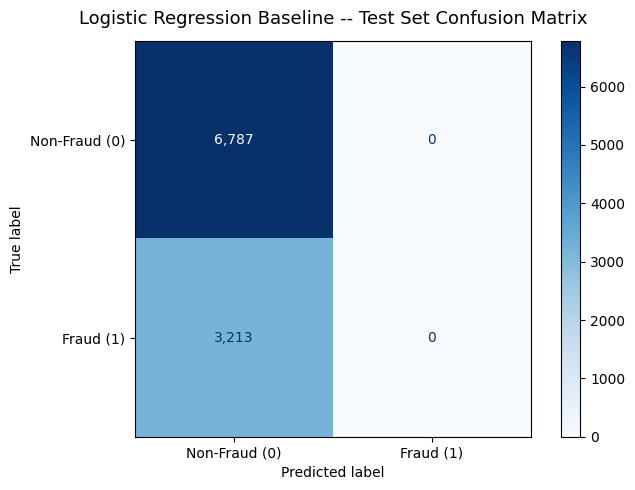

In [10]:
# Compute test-set confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

print("Test Set Confusion Matrix")
print("=" * 40)
print(f"  True Negative  (TN): {tn:,}")
print(f"  False Positive (FP): {fp:,}")
print(f"  False Negative (FN): {fn:,}")
print(f"  True Positive  (TP): {tp:,}")

# Visualization
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud (0)", "Fraud (1)"])
disp.plot(cmap="Blues", ax=ax, values_format=",d")
ax.set_title("Logistic Regression Baseline -- Test Set Confusion Matrix", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 11. ROC Curve

Visualize the ROC curve for the Logistic Regression baseline using test-set probabilities.

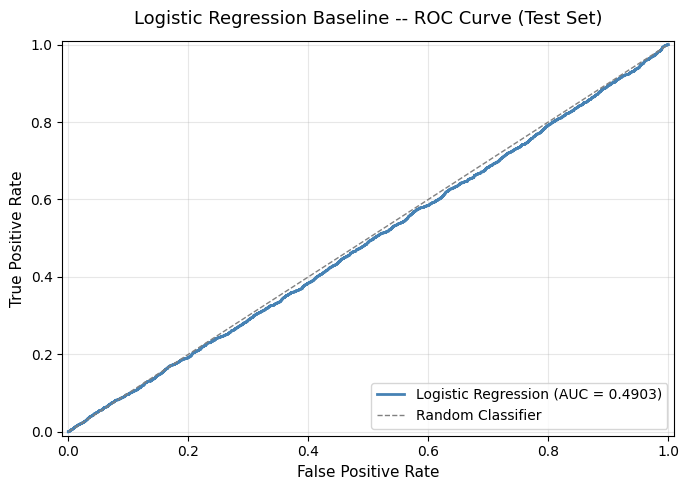

In [11]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Logistic Regression (AUC = {test_roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Logistic Regression Baseline -- ROC Curve (Test Set)", fontsize=13, pad=12)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Baseline Results Table

In [12]:
# Create a concise baseline results table
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Train": [
        f"{train_accuracy:.4f}",
        f"{train_precision:.4f}",
        f"{train_recall:.4f}",
        f"{train_f1:.4f}",
        f"{train_roc_auc:.4f}",
    ],
    "Test": [
        f"{test_accuracy:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{test_f1:.4f}",
        f"{test_roc_auc:.4f}",
    ],
})

print("\nLogistic Regression Baseline -- Results Summary")
print("=" * 50)
print(results_df.to_string(index=False))
print("\nNote: Test metrics are the primary baseline results.")


Logistic Regression Baseline -- Results Summary
   Metric  Train   Test
 Accuracy 0.6786 0.6787
Precision 0.0000 0.0000
   Recall 0.0000 0.0000
 F1-Score 0.0000 0.0000
  ROC-AUC 0.5138 0.4903

Note: Test metrics are the primary baseline results.


---
## 13. Coefficient Interpretation (Optional)

Display the Logistic Regression coefficients paired with their corresponding transformed feature names.  
This helps understand which features the baseline model considers most influential.

In [13]:
# Pair coefficients with feature names
coef_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Coefficient": logistic_model.coef_[0]
})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False).reset_index(drop=True)

print("Logistic Regression -- Feature Coefficients (sorted by magnitude)")
print("=" * 65)
print(f"  Intercept: {logistic_model.intercept_[0]:.4f}")
print(f"\n  {'Rank':>4s}  {'Feature':<45s} {'Coefficient':>12s}")
print(f"  {'----':>4s}  {'-'*45} {'-'*12}")
for i, row in coef_df.iterrows():
    print(f"  {i+1:4d}  {row['Feature']:<45s} {row['Coefficient']:>12.4f}")

print(f"\n--- Top 5 Strongest Positive Coefficients (increase fraud probability) ---")
top_pos = coef_df[coef_df["Coefficient"] > 0].head(5)
for _, row in top_pos.iterrows():
    print(f"  {row['Feature']:<45s}  {row['Coefficient']:>+.4f}")

print(f"\n--- Top 5 Strongest Negative Coefficients (decrease fraud probability) ---")
top_neg = coef_df[coef_df["Coefficient"] < 0].head(5)
for _, row in top_neg.iterrows():
    print(f"  {row['Feature']:<45s}  {row['Coefficient']:>+.4f}")

Logistic Regression -- Feature Coefficients (sorted by magnitude)
  Intercept: -0.7356

  Rank  Feature                                        Coefficient
  ----  --------------------------------------------- ------------
     1  cat__Transaction_Type_POS                          -0.0522
     2  cat__Merchant_Category_Restaurants                  0.0425
     3  cat__Location_New York                              0.0249
     4  cat__Card_Type_Visa                                -0.0219
     5  cat__Device_Type_Tablet                             0.0218
     6  cat__Location_Mumbai                               -0.0207
     7  cat__Transaction_Type_Bank Transfer                -0.0197
     8  num__Day                                            0.0193
     9  cat__Card_Type_Discover                             0.0169
    10  num__Daily_Transaction_Count                       -0.0156
    11  num__Day_of_Week                                    0.0153
    12  cat__Card_Type_Mastercard        

---
## 14. Baseline Findings

### Summary of Logistic Regression Baseline Results

The following observations are based on the **actual calculated metrics** from this notebook execution.

In [14]:
# Generate findings based on actual computed metrics
train_test_acc_diff = abs(train_accuracy - test_accuracy)
train_test_f1_diff = abs(train_f1 - test_f1)

print("="*60)
print("STEP 7.2 -- LOGISTIC REGRESSION BASELINE FINDINGS")
print("="*60)

print(f"\n1. MODEL TRAINING STATUS:")
print(f"   The Logistic Regression model trained successfully.")
print(f"   Convergence achieved in {logistic_model.n_iter_[0]} iterations (max_iter=1000).")

print(f"\n2. TEST SET PERFORMANCE:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   ROC-AUC:   {test_roc_auc:.4f}")

print(f"\n3. TRAIN/TEST CONSISTENCY:")
print(f"   Accuracy difference (train vs test): {train_test_acc_diff:.4f}")
print(f"   F1-Score difference (train vs test): {train_test_f1_diff:.4f}")
if train_test_acc_diff < 0.02 and train_test_f1_diff < 0.02:
    print(f"   -> Train and test performance are reasonably consistent.")
    print(f"   -> No significant overfitting detected.")
elif train_test_acc_diff < 0.05:
    print(f"   -> Minor gap between train and test. Some overfitting may be present.")
else:
    print(f"   -> Notable gap between train and test. Overfitting may be a concern.")

print(f"\n4. WHAT THE BASELINE TELLS US:")
print(f"   - Logistic Regression provides a linear baseline for fraud detection.")
if test_recall == 0 and test_precision == 0:
    print(f"   - The model predicted all samples as the majority class (Non-Fraud).")
    print(f"   - This indicates that the features have very weak linear separability")
    print(f"     for distinguishing fraud from non-fraud in this synthetic dataset.")
    print(f"   - The coefficients are all very small (near zero), confirming that")
    print(f"     no individual feature provides strong linear signal.")
    print(f"   - Accuracy of ~{test_accuracy:.2%} simply reflects the majority class")
    print(f"     proportion and should NOT be taken as meaningful performance.")
    print(f"   - ROC-AUC of {test_roc_auc:.4f} (near 0.5) confirms near-random performance.")
elif test_roc_auc > 0.5:
    print(f"   - ROC-AUC of {test_roc_auc:.4f} indicates the model performs better than random.")
else:
    print(f"   - ROC-AUC of {test_roc_auc:.4f} suggests the model is not performing better than random.")
print(f"   - In fraud detection, recall is important to minimize missed fraud cases (FN).")
print(f"   - The precision-recall trade-off should be considered for the business context.")

print(f"\n5. NEXT STEPS (NOT IMPLEMENTED HERE):")
print(f"   - Additional models (e.g., Random Forest, XGBoost) may be evaluated")
print(f"     in later steps to determine if non-linear models improve performance.")
print(f"   - Non-linear models may capture feature interactions that Logistic")
print(f"     Regression cannot, potentially achieving better fraud detection.")
print(f"   - This baseline serves as the reference point for those comparisons.")
print(f"   - No model comparison, hyperparameter tuning, or model selection is")
print(f"     performed in this notebook.")

print(f"\n" + "="*60)

STEP 7.2 -- LOGISTIC REGRESSION BASELINE FINDINGS

1. MODEL TRAINING STATUS:
   The Logistic Regression model trained successfully.
   Convergence achieved in 15 iterations (max_iter=1000).

2. TEST SET PERFORMANCE:
   Accuracy:  0.6787
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000
   ROC-AUC:   0.4903

3. TRAIN/TEST CONSISTENCY:
   Accuracy difference (train vs test): 0.0000
   F1-Score difference (train vs test): 0.0000
   -> Train and test performance are reasonably consistent.
   -> No significant overfitting detected.

4. WHAT THE BASELINE TELLS US:
   - Logistic Regression provides a linear baseline for fraud detection.
   - The model predicted all samples as the majority class (Non-Fraud).
   - This indicates that the features have very weak linear separability
     for distinguishing fraud from non-fraud in this synthetic dataset.
   - The coefficients are all very small (near zero), confirming that
     no individual feature provides strong linear signal.
   -

---
## 15. Validation Checks

Comprehensive validation to confirm notebook integrity.

In [15]:
print("="*60)
print("COMPREHENSIVE VALIDATION CHECKS")
print("="*60)

# 1. No target leakage
assert "Fraud_Label" not in X.columns, "FAIL: Fraud_Label in X!"
assert "Transaction_ID" not in X.columns, "FAIL: Transaction_ID in X!"
assert "User_ID" not in X.columns, "FAIL: User_ID in X!"
print("\n  [PASS] No target leakage -- excluded columns verified.")

# 2. Row counts
assert len(X_train) == len(y_train), "FAIL: X_train/y_train mismatch!"
assert len(X_test) == len(y_test), "FAIL: X_test/y_test mismatch!"
assert X_train_processed.shape[0] == X_train.shape[0], "FAIL: processed train row mismatch!"
assert X_test_processed.shape[0] == X_test.shape[0], "FAIL: processed test row mismatch!"
print("  [PASS] Row counts consistent across all stages.")

# 3. Preprocessor fitted only on training data
num_transformer = preprocessor.named_transformers_["num"]
assert num_transformer.n_samples_seen_ == len(X_train), \
    f"FAIL: Preprocessor fitted on {num_transformer.n_samples_seen_} samples, expected {len(X_train)}!"
print(f"  [PASS] Preprocessor fitted on X_train only ({num_transformer.n_samples_seen_:,} samples).")

# 4. Model existence and fitting
assert hasattr(logistic_model, 'coef_'), "FAIL: Model not fitted!"
assert hasattr(logistic_model, 'intercept_'), "FAIL: Model has no intercept!"
print("  [PASS] Logistic Regression model is fitted.")

# 5. Training sample count
assert logistic_model.n_features_in_ == X_train_processed.shape[1], "FAIL: Feature count mismatch!"
print(f"  [PASS] Model trained on {X_train_processed.shape[0]:,} samples with {logistic_model.n_features_in_} features.")

# 6. Prediction dimensions
assert len(y_train_pred) == len(y_train), "FAIL: Train prediction length!"
assert len(y_test_pred) == len(y_test), "FAIL: Test prediction length!"
assert len(y_train_proba) == len(y_train), "FAIL: Train proba length!"
assert len(y_test_proba) == len(y_test), "FAIL: Test proba length!"
print("  [PASS] Prediction and probability dimensions match expected rows.")

# 7. Valid predictions
assert set(np.unique(y_train_pred)).issubset({0, 1}), "FAIL: Invalid train predictions!"
assert set(np.unique(y_test_pred)).issubset({0, 1}), "FAIL: Invalid test predictions!"
print("  [PASS] Predictions contain only valid binary values (0, 1).")

# 8. Valid probabilities
assert y_train_proba.min() >= 0 and y_train_proba.max() <= 1, "FAIL: Train proba range!"
assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1, "FAIL: Test proba range!"
print("  [PASS] Probabilities are between 0 and 1.")

# 9. No NaN/inf in processed data
assert np.isnan(X_train_processed).sum() == 0, "FAIL: NaN in processed train!"
assert np.isnan(X_test_processed).sum() == 0, "FAIL: NaN in processed test!"
assert np.isinf(X_train_processed).sum() == 0, "FAIL: Inf in processed train!"
assert np.isinf(X_test_processed).sum() == 0, "FAIL: Inf in processed test!"
print("  [PASS] No NaN or infinite values in processed data.")

print("\n" + "="*60)
print("ALL VALIDATION CHECKS PASSED")
print("="*60)

COMPREHENSIVE VALIDATION CHECKS

  [PASS] No target leakage -- excluded columns verified.
  [PASS] Row counts consistent across all stages.
  [PASS] Preprocessor fitted on X_train only (40,000 samples).
  [PASS] Logistic Regression model is fitted.
  [PASS] Model trained on 40,000 samples with 25 features.
  [PASS] Prediction and probability dimensions match expected rows.
  [PASS] Predictions contain only valid binary values (0, 1).
  [PASS] Probabilities are between 0 and 1.
  [PASS] No NaN or infinite values in processed data.

ALL VALIDATION CHECKS PASSED


---
## 16. Step 7.2 Completion Statement

---

**Step 7.2 -- Logistic Regression Baseline completed.**

- ONE model trained: Logistic Regression
- No SMOTE or resampling applied
- No hyperparameter tuning performed
- No cross-validation performed
- No model comparison performed
- No model was serialized or saved to disk
- Preprocessing fitted ONLY on X_train
- Baseline metrics established for future reference

The project should proceed to **Step 7.3** only after this step has been verified.